M1: mu ~ N(0, I), y|mu ~ N(mu, I)
with MMD summary space regularization
D=20
N=100

In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

import pickle
import pandas as pd
import matplotlib.pyplot as plt
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
from benchmark.examples.gaussian.analytic.analytic import GaussianAnalytical
from benchmark.examples.gaussian.npe.estimation import MarginalLikelihoodEstimator


INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [3]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=100
mu_prior_mean=0
mu_prior_std=1
likelihood_std=1

In [4]:
# simulator
def prior(mu=mu_prior_mean, sigma=mu_prior_std):
    mu = RNG.normal(loc=mu, scale=sigma, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [5]:
# adapter 
adapter = (bf.adapters.Adapter()
                        .convert_dtype("float64", "float32")
                        .rename('mu', 'inference_variables')
                        .rename('x', 'summary_variables')
                )

In [6]:
# networks
summary_net = bf.networks.DeepSet(
    summary_dim=6 * num_dims, base_distribution="normal"
)

inference_net = bf.networks.CouplingFlow()

In [7]:
workflow = bf.BasicWorkflow(simulator=simulator,
                                          adapter=adapter,
                                          summary_network=summary_net,
                                          inference_network=inference_net,
                                          standardize="all"
                                          )
epochs=100
batch_size=64
num_batches_per_epoch=128
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
workflow.approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [8]:
history = workflow.fit_online(epochs=epochs,batch_size=batch_size,num_batches_per_epoch=num_batches_per_epoch)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 21.4630 - loss/inference_loss: 20.7059 - loss/summary_loss: 0.7572
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 14.1416 - loss/inference_loss: 13.4710 - loss/summary_loss: 0.6706
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 9.5202 - loss/inference_loss: 8.9752 - loss/summary_loss: 0.5450  
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 5.9782 - loss/inference_loss: 5.4852 - loss/summary_loss: 0.4930
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 2.6265 - loss/inference_loss: 2.1935 - loss/summary_loss: 0.4330
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: -0.0549 - loss/inference_loss: -0.4325 - loss/summary_loss: 0.3776
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: -2.4199 - loss/inference_loss: -2.7697 - loss/summary_loss: 0.3499
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: -2.6684 - loss/inference_loss: -2.9936 

INFO:bayesflow:Training completed in 13.04 minutes.


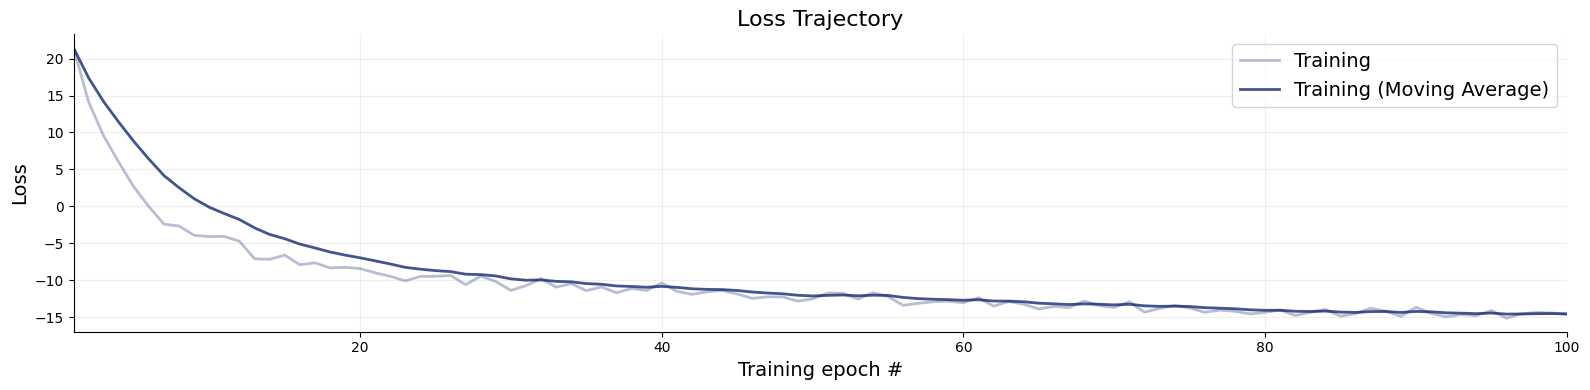

In [9]:
f=bf.diagnostics.plots.loss(history)

In [10]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()


INFO:bayesflow:Sampling completed in 2.07 seconds.


dict_keys(['mu'])

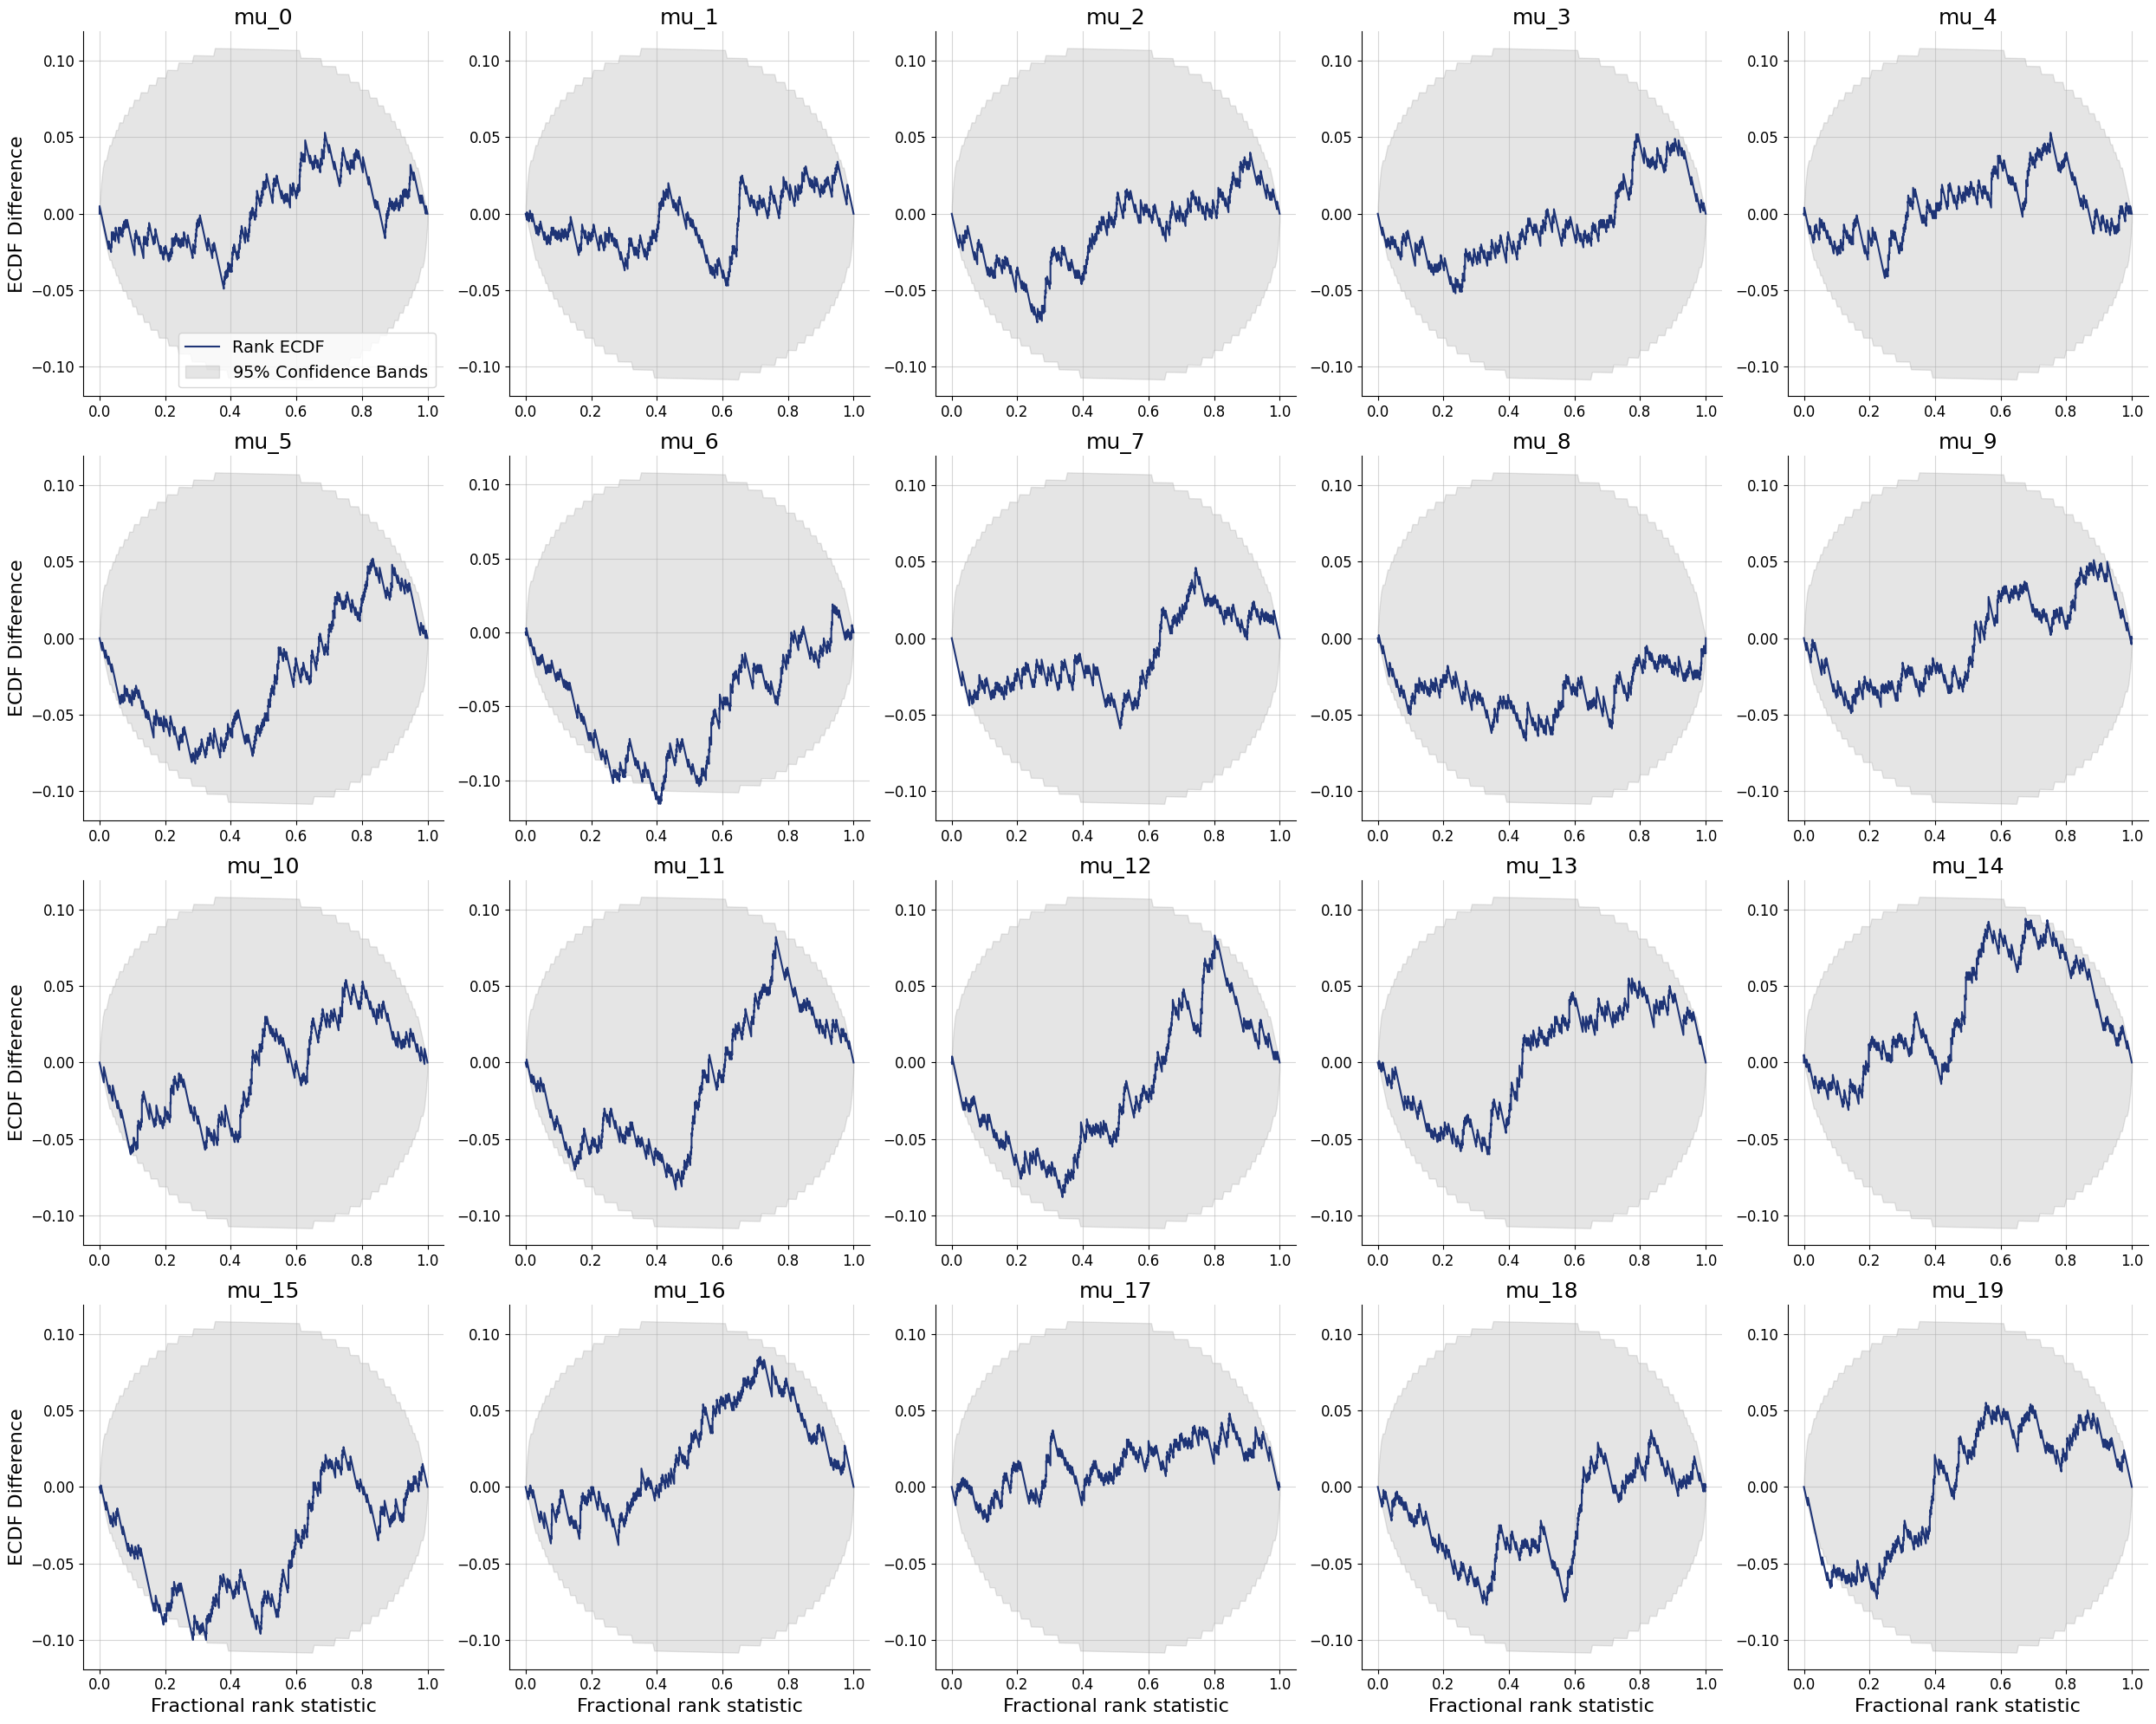

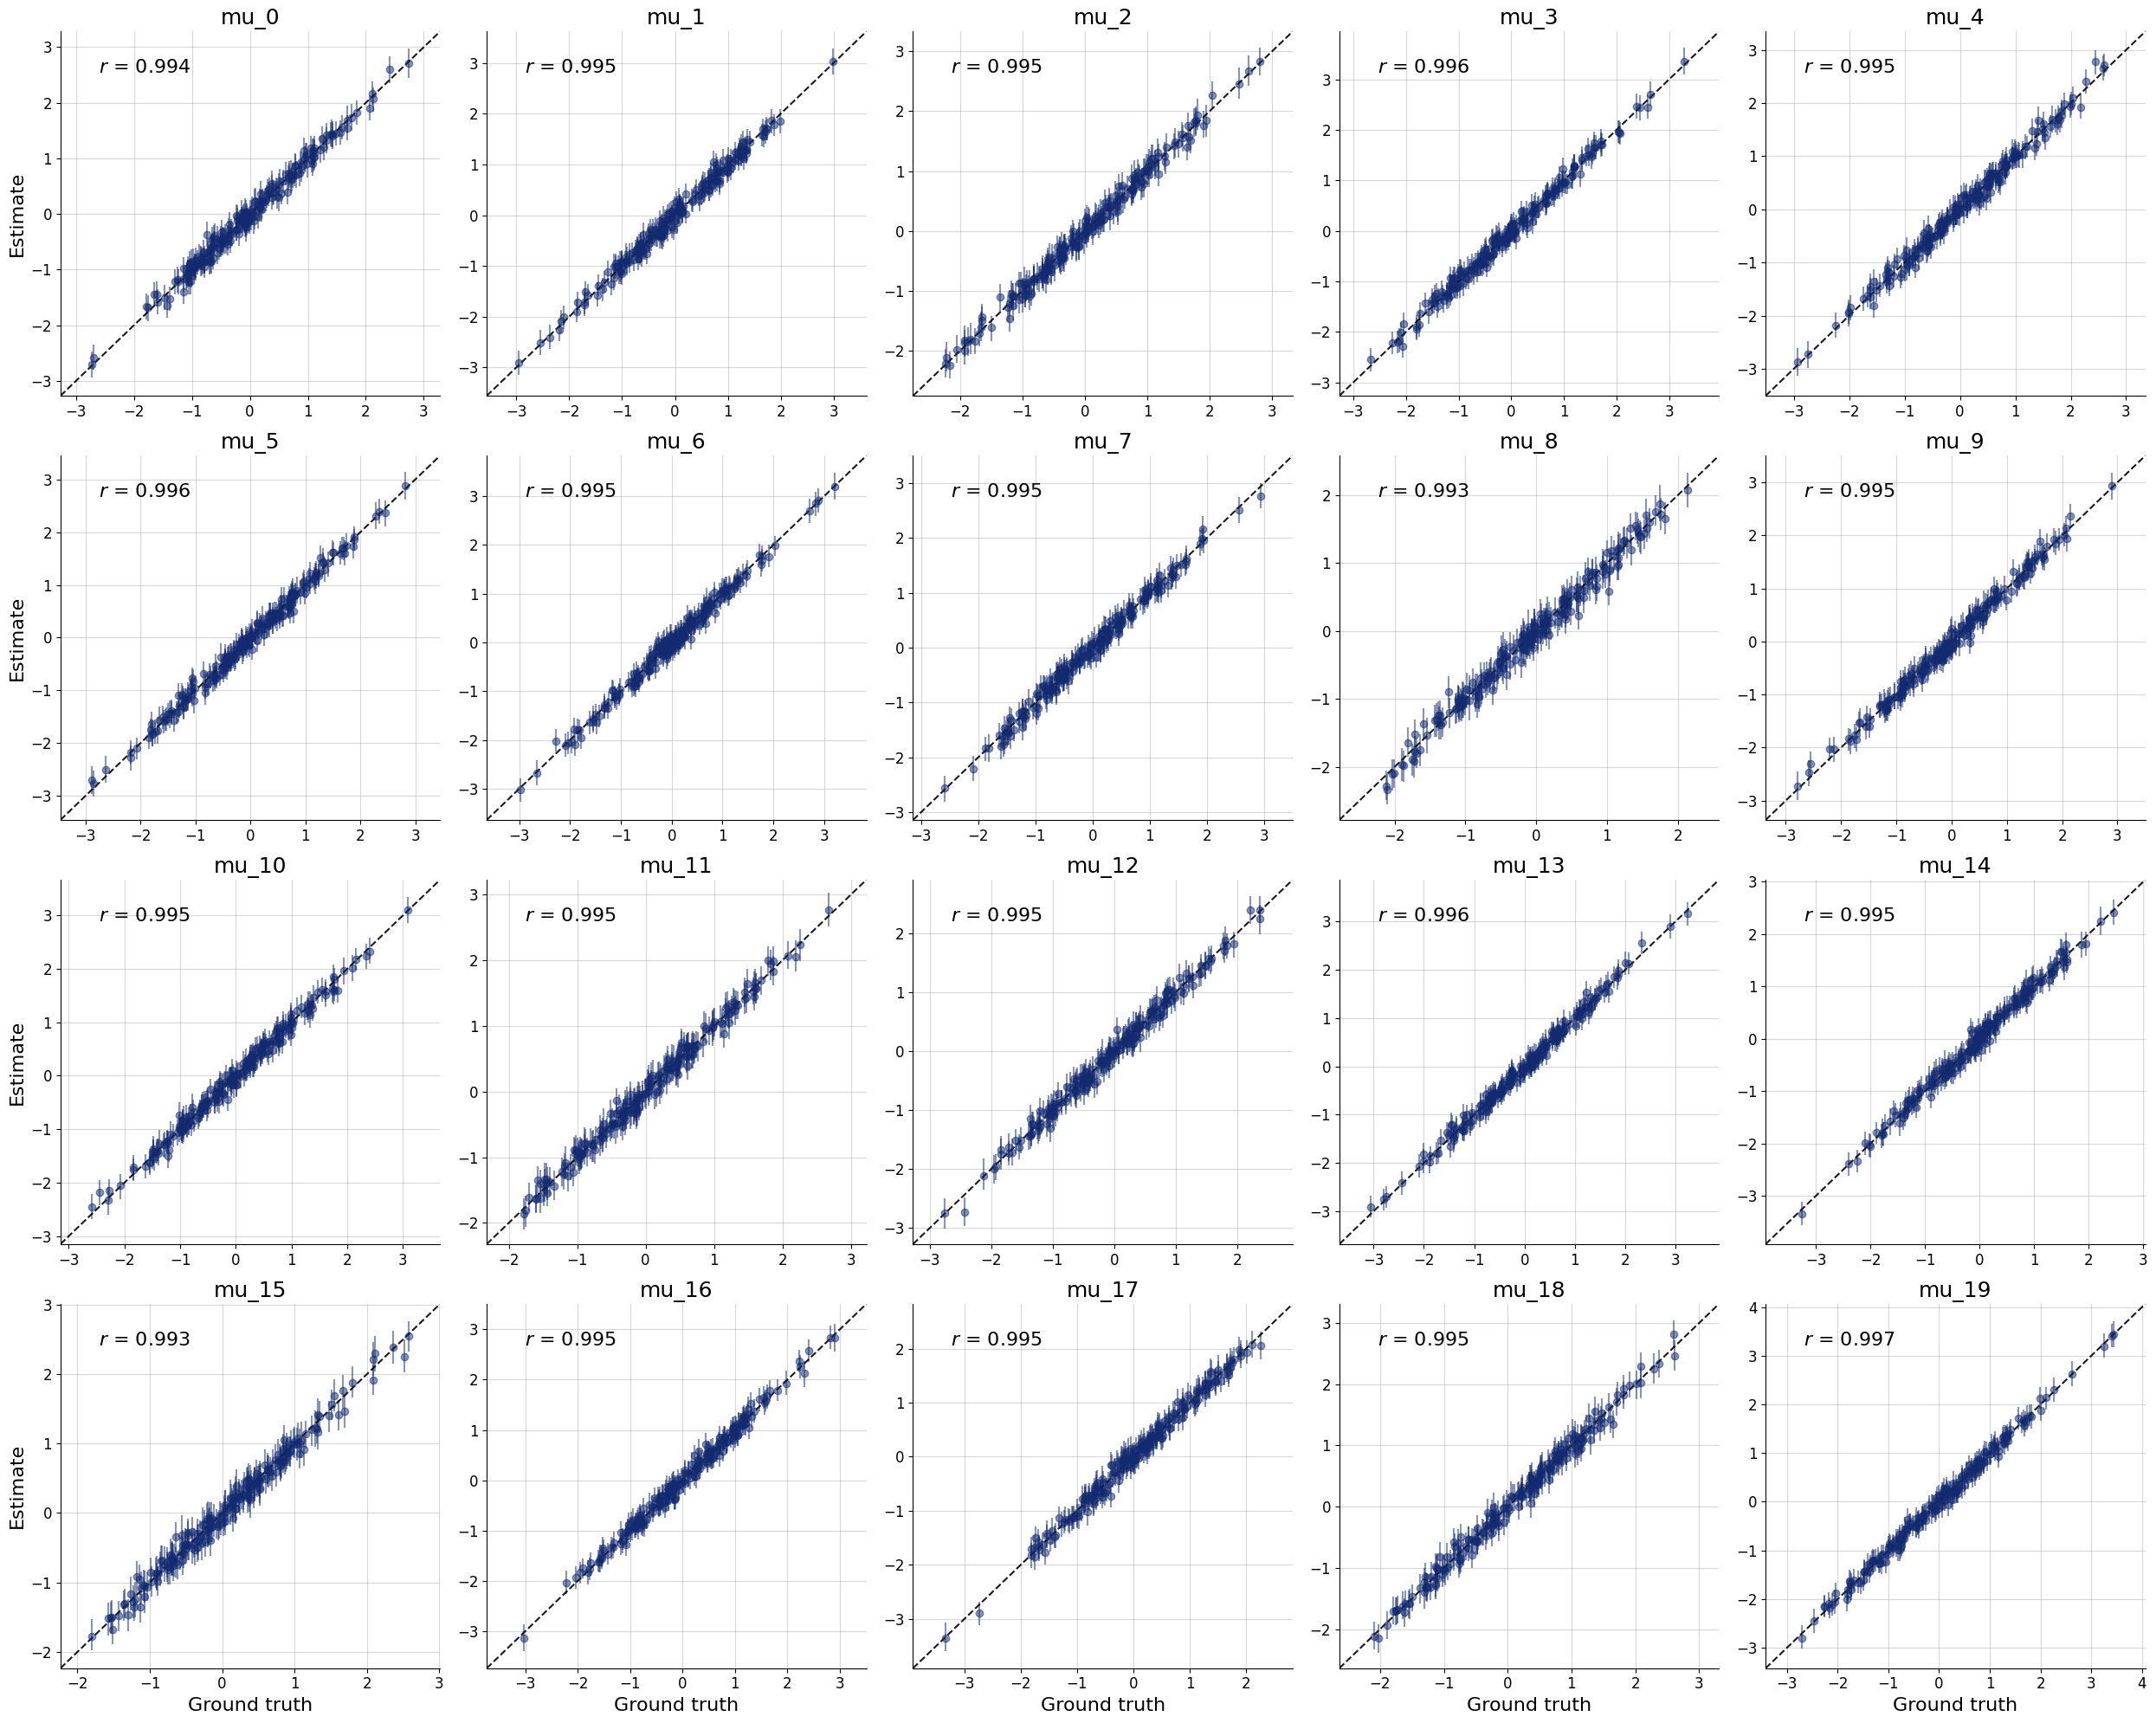

In [11]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [12]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m1_s_20d_100n.keras"
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [13]:
# load approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m1_s_20d_100n.keras"
approximator = keras.saving.load_model(filepath)

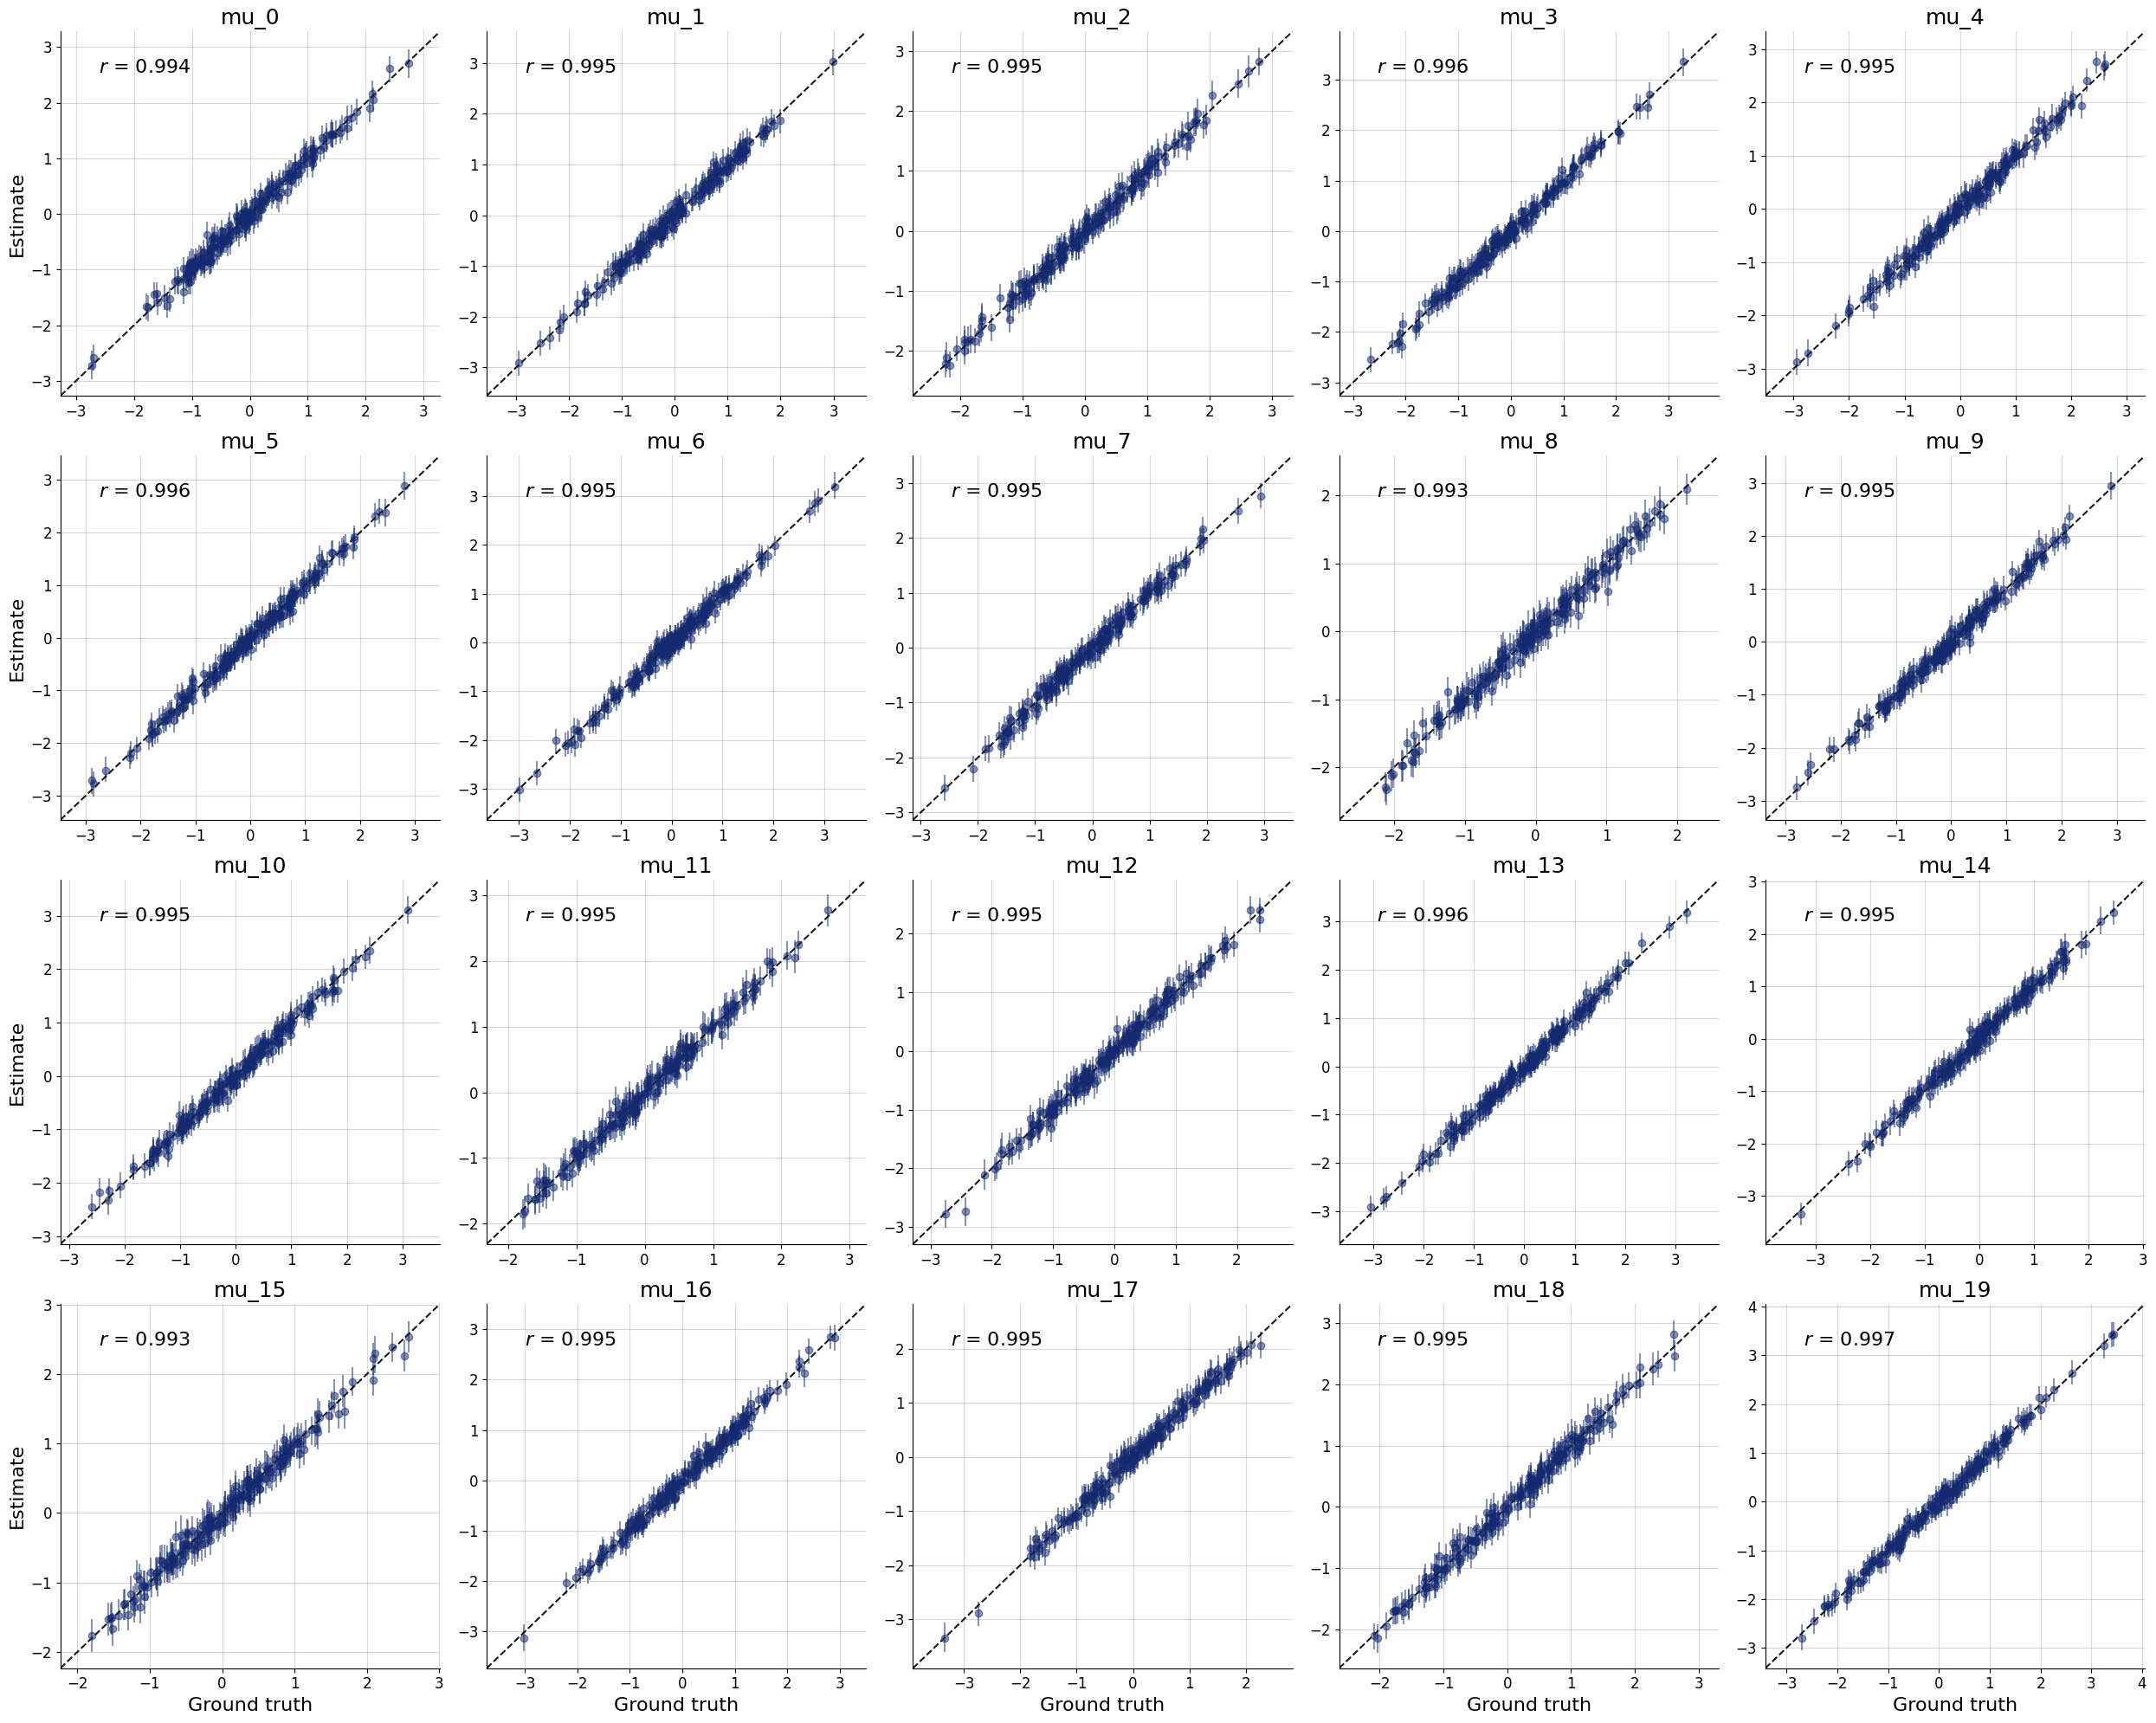

In [14]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Reference distribution of summary-space Mahalanobis distance'}, xlabel='Mahalanobis distance $d_M$', ylabel='Density'>)

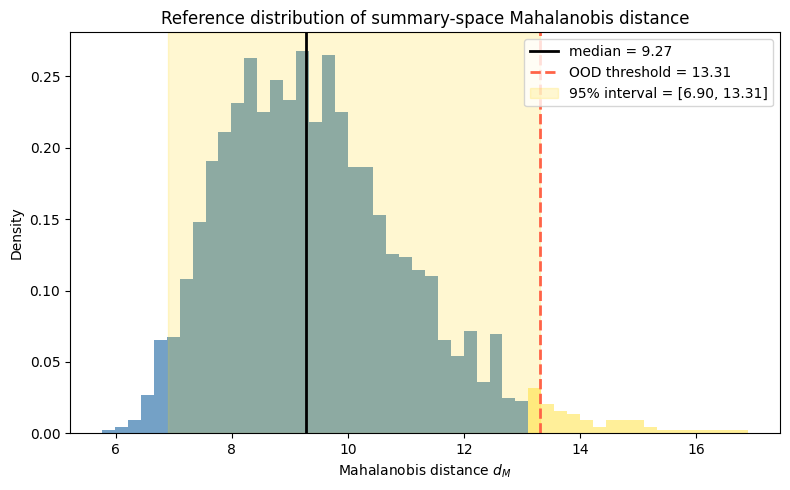

In [15]:
model_path = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks/m1_s_20d_100n.keras")
dataset_dir = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/datasets")

approximator = sd.load_approximator(model_path)
ref = sd.fit_reference(approximator, simulator, n_ref=2000)

sd.plot_reference(ref)


In [16]:
# df_logml = sd.collect_metric_relation(
#     approximator,
#     dataset_dir,
#     ref,
#     sources=["m1", "m2", "m3", "m4"],
#     metric_fn=sd.signed_logml_error("m1"),
#     metric_name="signed_logml_error_m1",
# )
# labels = {
#     "m1": "M1 (well_specified)",
#     "m2": "M2 (prior misspecification)",
#     "m3": "M3 (likelihood misspecification)",
#     "m4": "M4 (open_world)",
# }
# summary = sd.empirical_summary(df_logml, "signed_logml_error_m1", labels=labels)
# display(sd.format_summary(summary, "signed_logml_error_m1"))

# sd.plot_metric_relation(df_logml, summary, "signed_logml_error_m1", ref, labels=labels)